#  Modélisation et Machine Learning pour la prédiction de la résistance du béton

## Objectif général

Ce notebook fait suite au notebook  consacré à l'étude exploratoire des données.

L'objectif est maintenant de construire plusieurs modèles de Machine Learning capables de répondre à une question métier centrale en génie civil :

> **À partir d'une formulation donnée, peut-on prédire la résistance à la compression du béton ?**

Cette problématique est très importante pour une centrale à béton, un laboratoire ou un ingénieur formulation, car elle peut aider à :

- anticiper la résistance probable avant les essais à 28 jours ;
- réduire le nombre d'essais expérimentaux coûteux ;
- comparer plusieurs formulations candidates ;
- aider à proposer une composition proche d'une performance demandée par un client ;
- préparer une approche inverse inspirée de l'article de Nasser et al.



## 1. Importation des bibliothèques

### Utilité dans le projet de génie civil

Cette étape prépare les outils nécessaires pour :

- lire le dataset ;
- séparer les données en apprentissage et test ;
- entraîner plusieurs modèles ;
- mesurer les erreurs de prédiction ;
- produire des graphiques d'interprétation.

Dans un contexte de génie civil, les métriques d'erreur comme `MAE` ou `RMSE` sont très utiles car elles s'expriment directement dans l'unité de la résistance, c'est-à-dire en MPa.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

## 2. Chargement du dataset fusionné

### Utilité dans le projet

On charge le même dataset utilisé dans l'EDA.

Chaque ligne représente une formulation de béton.  
La variable à prédire est `Resistance`.

Les autres variables représentent les paramètres de formulation disponibles :

- ciment ;
- eau ;
- superplastifiant ;
- granulats ;
- âge ;
- rapports déjà présents dans le fichier, comme `E/C` et `G/S`.

Ces informations sont utilisées pour apprendre la relation :

> **Composition du béton → Résistance à la compression**

In [2]:
dataset_path = Path("dataset_concrete_formulations_final.csv")

df = pd.read_csv(dataset_path)

print("Dataset chargé avec succès.")
print("Dimensions :", df.shape)
display(df.head())

print("\nColonnes disponibles :")
print(df.columns.tolist())

Dataset chargé avec succès.
Dimensions : (302, 9)


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance
0,540.0,162.0,2.5,1040.0,676.0,1.538,0.30,28,79.99
1,540.0,162.0,2.5,1055.0,676.0,1.561,0.30,28,61.89
2,475.0,228.0,0.0,932.0,594.0,1.569,0.48,28,39.29
3,380.0,228.0,0.0,932.0,670.0,1.391,0.60,90,52.91
4,475.0,228.0,0.0,932.0,594.0,1.569,0.48,180,42.62



Colonnes disponibles :
['Ciment', 'Eau', 'Superplastifiant', 'Granulats_grossiers', 'Granulats_fins', 'G/S', 'E/C', 'Age', 'Resistance']


## 3. Vérification rapide avant modélisation

### Utilité dans le projet

Avant d'entraîner des modèles, on vérifie :

- l'absence de valeurs manquantes ;
- les types des variables ;
- la présence de la variable cible `Resistance`.

Un modèle de Machine Learning peut donner de mauvais résultats si les données contiennent des valeurs manquantes ou des colonnes non numériques non traitées.

In [3]:
print("Types des colonnes :")
display(df.dtypes.to_frame("Type"))

print("\nValeurs manquantes :")
display(df.isna().sum().to_frame("Nombre de valeurs manquantes"))

print("\nNombre de doublons :", df.duplicated().sum())

if "Resistance" not in df.columns:
    raise ValueError("La colonne 'Resistance' est absente du dataset.")

Types des colonnes :


,Type
Ciment,float64
Eau,float64
Superplastifiant,float64
Granulats_grossiers,float64
Granulats_fins,float64
G/S,float64
E/C,float64
Age,int64
Resistance,float64



Valeurs manquantes :


,Nombre de valeurs manquantes
Ciment,0
Eau,0
Superplastifiant,0
Granulats_grossiers,0
Granulats_fins,0
G/S,0
E/C,0
Age,0
Resistance,0



Nombre de doublons : 1


## 4. Choix des variables d'entrée et de la variable cible

### Utilité dans le projet

La variable cible est :

- `Resistance` : résistance à la compression.

Les variables d'entrée sont toutes les autres colonnes numériques disponibles.

Cette étape correspond au choix des informations que l'on donne au modèle pour qu'il apprenne à prédire la résistance.

In [4]:
target_col = "Resistance"

# On garde uniquement les colonnes numériques, car les modèles utilisés ici travaillent sur des valeurs numériques.
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

feature_cols = [col for col in numeric_cols if col != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Variable cible :", target_col)
print("Variables explicatives utilisées :")
for col in feature_cols:
    print("-", col)

print("\nDimensions de X :", X.shape)
print("Dimensions de y :", y.shape)

Variable cible : Resistance
Variables explicatives utilisées :
- Ciment
- Eau
- Superplastifiant
- Granulats_grossiers
- Granulats_fins
- G/S
- E/C
- Age

Dimensions de X : (302, 8)
Dimensions de y : (302,)


## 5. Visualisation des relations avant apprentissage

### Utilité dans le projet

Avant d'entraîner les modèles, il est utile de revoir graphiquement les relations entre les variables d'entrée et la résistance.

Ces graphiques permettent de voir si la relation semble :

- linéaire ;
- non linéaire ;
- dispersée ;
- influencée par des valeurs extrêmes.

Ce diagnostic aide à comprendre pourquoi certains modèles simples peuvent être insuffisants, et pourquoi des modèles non linéaires comme Random Forest ou Gradient Boosting peuvent mieux fonctionner.

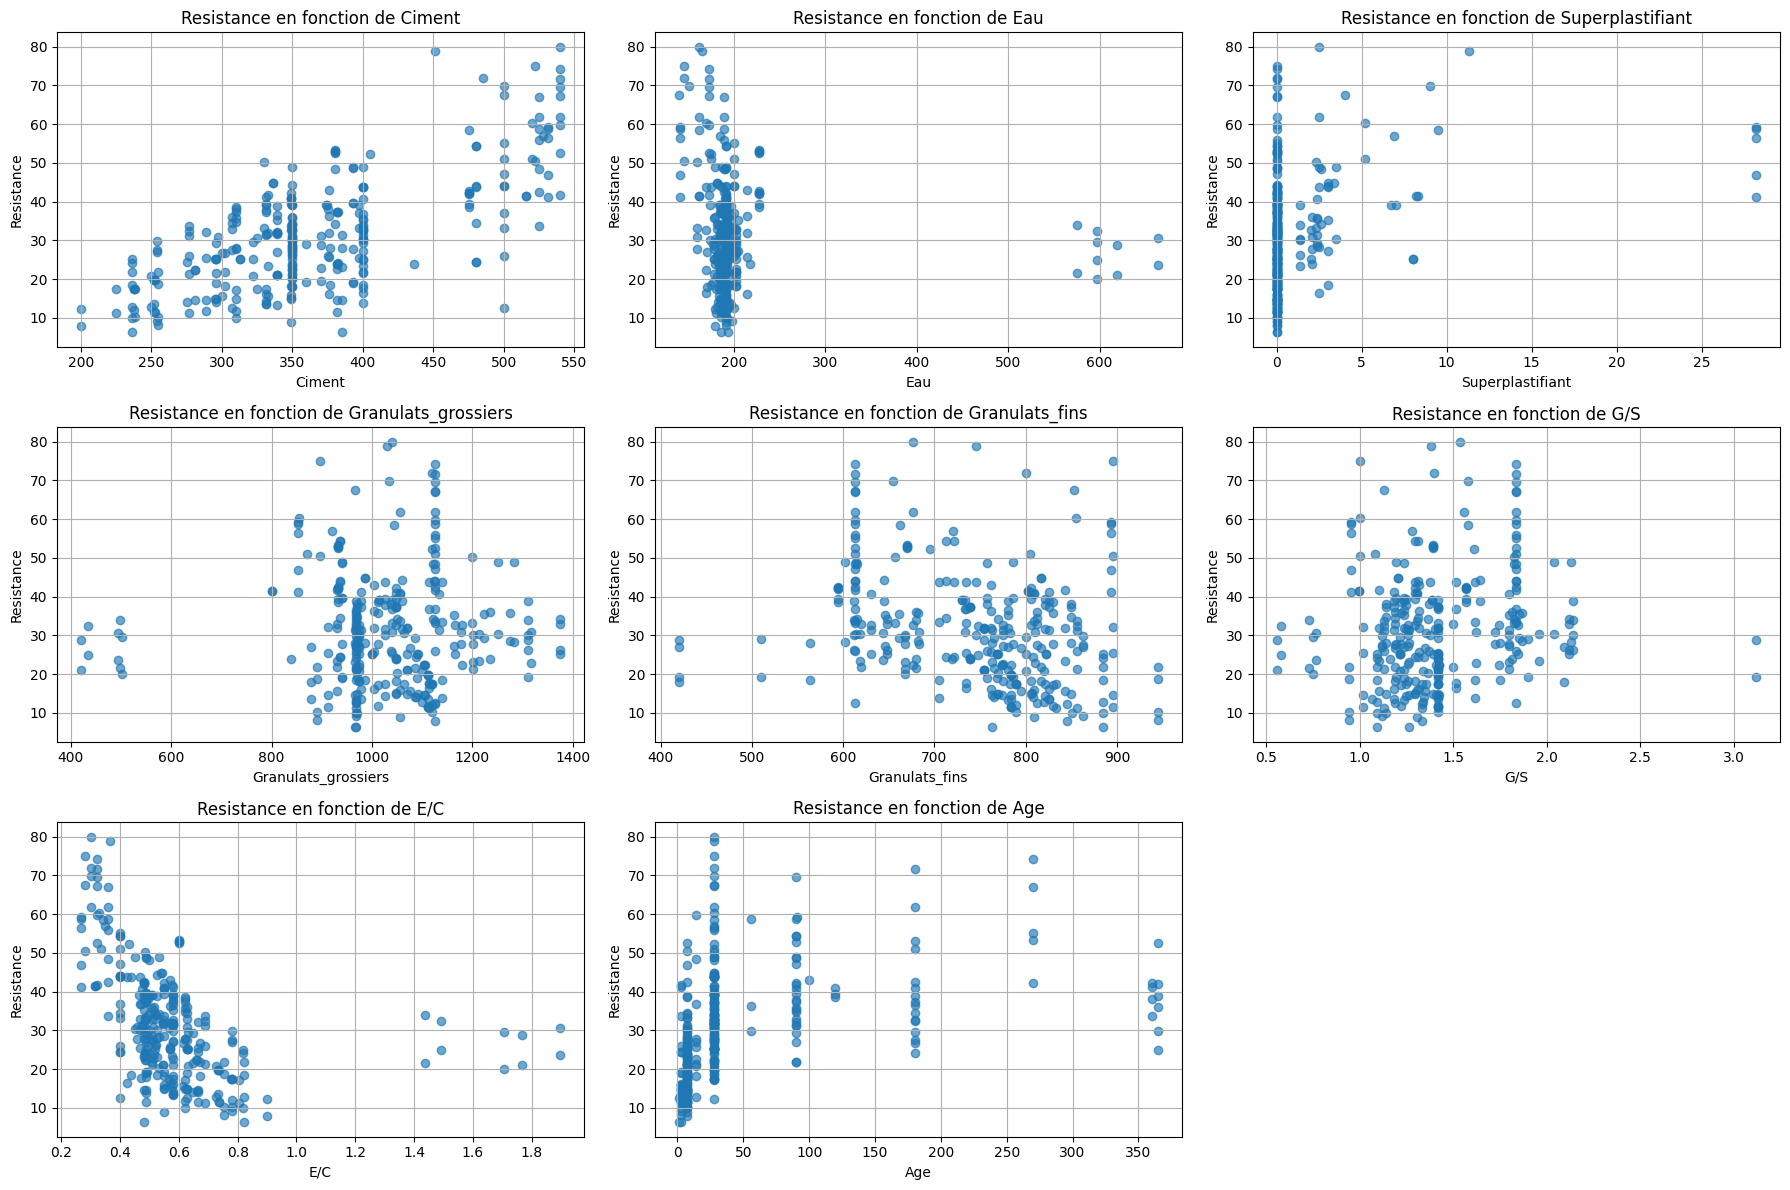

In [5]:
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(X[col], y, alpha=0.65)
    axes[i].set_title(f"Resistance en fonction de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Resistance")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 6. Séparation apprentissage / test

### Utilité dans le projet

On sépare les données en deux parties :

- **jeu d'apprentissage** : utilisé pour entraîner les modèles ;
- **jeu de test** : utilisé pour vérifier la capacité du modèle à prédire des formulations qu'il n'a jamais vues.

Dans un contexte de génie civil, cette séparation est essentielle.  
Un modèle ne doit pas seulement mémoriser les formulations connues : il doit être capable d'estimer la résistance de nouvelles formulations proposées par un ingénieur ou demandées par un client.

Taille du jeu d'apprentissage : (241, 8)
Taille du jeu de test : (61, 8)


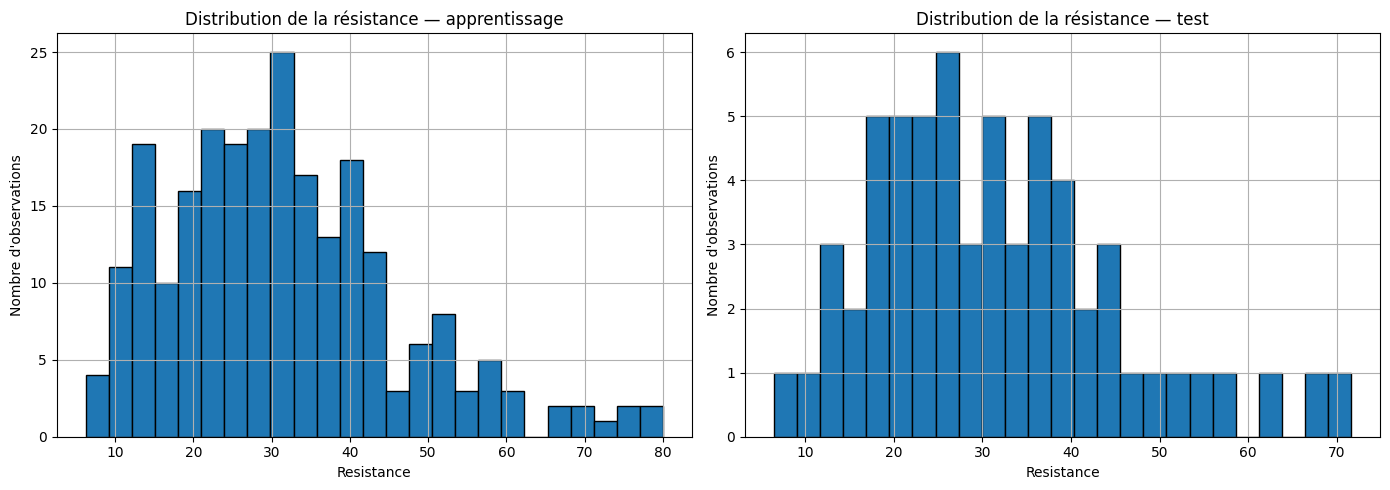

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Taille du jeu d'apprentissage :", X_train.shape)
print("Taille du jeu de test :", X_test.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_train, bins=25, edgecolor="black")
axes[0].set_title("Distribution de la résistance — apprentissage")
axes[0].set_xlabel("Resistance")
axes[0].set_ylabel("Nombre d'observations")

axes[1].hist(y_test, bins=25, edgecolor="black")
axes[1].set_title("Distribution de la résistance — test")
axes[1].set_xlabel("Resistance")
axes[1].set_ylabel("Nombre d'observations")

plt.tight_layout()
plt.show()

## 7. Définition des métriques d'évaluation

### Utilité dans le projet de génie civil

On utilise trois métriques principales :

### MAE — Mean Absolute Error

Erreur moyenne absolue.  
Elle indique l'erreur moyenne en MPa.

Exemple :  
si `MAE = 3 MPa`, cela signifie qu'en moyenne le modèle se trompe d'environ 3 MPa.

### RMSE — Root Mean Squared Error

Erreur quadratique moyenne.  
Elle pénalise davantage les grandes erreurs.

C'est utile en génie civil, car une forte erreur sur une formulation peut conduire à un risque de non-conformité.

### R² — Coefficient de détermination

Il mesure la part de variabilité de la résistance expliquée par le modèle.

- proche de 1 : très bon modèle ;
- proche de 0 : modèle faible ;
- négatif : modèle moins bon qu'une prédiction par la moyenne.

In [7]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Entraîne un modèle, calcule les métriques et retourne les prédictions."""

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return {
        "Modèle": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "model": model,
        "y_pred": y_pred
    }

## 8. Modèle de référence : prédiction par la moyenne

### Utilité dans le projet

Avant de tester des modèles complexes, on construit une référence très simple :

> prédire toujours la résistance moyenne du jeu d'apprentissage.

Un vrai modèle de Machine Learning doit faire mieux que cette référence.

Cette étape permet donc de vérifier que les modèles apportent réellement une valeur ajoutée.

In [8]:
mean_prediction = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

baseline_mae = mean_absolute_error(y_test, mean_prediction)
baseline_rmse = np.sqrt(mean_squared_error(y_test, mean_prediction))
baseline_r2 = r2_score(y_test, mean_prediction)

baseline_result = {
    "Modèle": "Baseline moyenne",
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2,
    "model": None,
    "y_pred": mean_prediction
}

print("Résultats du modèle de référence")
print("MAE :", baseline_mae)
print("RMSE :", baseline_rmse)
print("R² :", baseline_r2)

Résultats du modèle de référence
MAE : 10.91838310319026
RMSE : 13.850176973504457
R² : -0.0004029198992576699


## 9. Modèles linéaires

### Utilité dans le projet

Les modèles linéaires sont simples et interprétables.

Ils supposent que la résistance peut être approximée par une combinaison linéaire des dosages.

Ils sont utiles comme première approche, mais ils peuvent être limités car le comportement du béton est souvent non linéaire :

- interaction entre eau et ciment ;
- effet de l'âge ;
- effet des granulats ;
- effet du superplastifiant.

On teste ici :

- Régression linéaire ;
- Ridge ;
- Lasso.

In [9]:
linear_models = {
    "Régression linéaire": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, random_state=42, max_iter=10000))
    ])
}

results = [baseline_result]

for name, model in linear_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)

pd.DataFrame([{k: v for k, v in r.items() if k not in ["model", "y_pred"]} for r in results])

,Modèle,MAE,RMSE,R2
0,Baseline moyenne,10.918,13.850,-4.029e-04
1,Régression linéaire,5.566,7.049,7.409e-01
2,Ridge,5.558,7.026,7.426e-01
3,Lasso,5.561,7.035,7.419e-01


## 10. Modèles non linéaires à base d'arbres

### Utilité dans le projet

Les modèles à base d'arbres sont très utiles pour les matériaux comme le béton, car ils peuvent capturer des relations non linéaires.

Ils peuvent apprendre des règles du type :

- si le rapport `E/C` est faible et l'âge élevé, la résistance augmente ;
- si l'eau est élevée, la résistance peut diminuer ;
- si le dosage en ciment est important, l'effet dépend aussi de l'eau et de l'âge.

On teste ici :

- Decision Tree ;
- Random Forest ;
- Extra Trees ;
- Gradient Boosting.

In [10]:
tree_models = {
    "Decision Tree": DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2
    ),
    "Extra Trees": ExtraTreesRegressor(
        n_estimators=300,
        random_state=42,
        min_samples_leaf=2
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}

for name, model in tree_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)

pd.DataFrame([{k: v for k, v in r.items() if k not in ["model", "y_pred"]} for r in results])

,Modèle,MAE,RMSE,R2
0,Baseline moyenne,10.918,13.850,-4.029e-04
1,Régression linéaire,5.566,7.049,7.409e-01
2,Ridge,5.558,7.026,7.426e-01
3,Lasso,5.561,7.035,7.419e-01
4,Decision Tree,3.988,5.755,8.273e-01
5,Random Forest,3.413,4.678,8.859e-01
6,Extra Trees,3.204,4.317,9.028e-01
7,Gradient Boosting,2.517,3.439,9.383e-01


## 11. Modèles avancés : SVR et réseau de neurones

### Utilité dans le projet

### SVR

Le SVR est capable de modéliser des relations non linéaires entre formulation et résistance.  
Il nécessite une normalisation des variables.

### Réseau de neurones

Le réseau de neurones est particulièrement intéressant ici, car l'article scientifique de Nasser et al. utilise justement des réseaux de neurones artificiels pour :

- prédire les performances du béton ;
- proposer des compositions à partir de performances cibles.

Dans ce notebook, on utilise un réseau de neurones simple `MLPRegressor` pour prédire la résistance à partir des variables existantes.

In [11]:
advanced_models = {
    "SVR": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=100, gamma="scale", epsilon=0.5))
    ]),
    "Réseau de neurones MLP": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32, 16),
            activation="relu",
            solver="adam",
            max_iter=3000,
            random_state=42,
            early_stopping=True
        ))
    ])
}

for name, model in advanced_models.items():
    result = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results.append(result)

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ["model", "y_pred"]} for r in results])
results_df = results_df.sort_values("RMSE")
display(results_df)

,Modèle,MAE,RMSE,R2
7,Gradient Boosting,2.517,3.439,9.383e-01
8,SVR,3.127,4.295,9.038e-01
6,Extra Trees,3.204,4.317,9.028e-01
5,Random Forest,3.413,4.678,8.859e-01
4,Decision Tree,3.988,5.755,8.273e-01
2,Ridge,5.558,7.026,7.426e-01
3,Lasso,5.561,7.035,7.419e-01
1,Régression linéaire,5.566,7.049,7.409e-01
9,Réseau de neurones MLP,6.356,8.020,6.646e-01
0,Baseline moyenne,10.918,13.850,-4.029e-04


## 12. Comparaison graphique des modèles

### Utilité dans le projet

Ce graphique permet de comparer rapidement les modèles selon leur erreur RMSE.

En génie civil, le RMSE est très parlant car il indique l'ordre de grandeur de l'erreur en MPa.

Un modèle avec un RMSE plus faible est plus intéressant pour prédire la résistance des formulations.

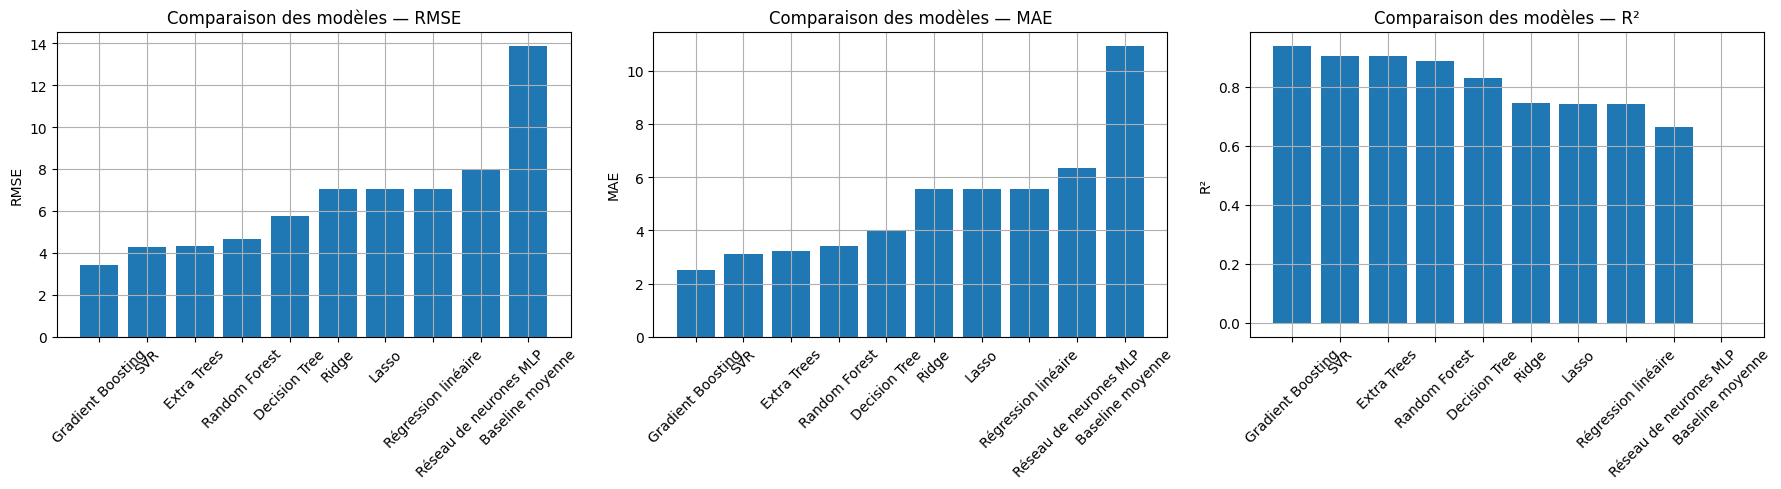

In [12]:
results_df_plot = results_df.sort_values("RMSE", ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results_df_plot["Modèle"], results_df_plot["RMSE"])
axes[0].set_title("Comparaison des modèles — RMSE")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(results_df_plot["Modèle"], results_df_plot["MAE"])
axes[1].set_title("Comparaison des modèles — MAE")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(results_df_plot["Modèle"], results_df_plot["R2"])
axes[2].set_title("Comparaison des modèles — R²")
axes[2].set_ylabel("R²")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 13. Graphiques prédiction réelle vs prédiction estimée

### Utilité dans le projet

Ces graphiques comparent :

- en abscisse : la résistance réelle mesurée ;
- en ordonnée : la résistance prédite par le modèle.

Un bon modèle doit produire des points proches de la diagonale.  
Plus les points s'éloignent de la diagonale, plus les erreurs sont importantes.

Cette visualisation est très utile pour voir si le modèle sous-estime ou surestime certaines résistances.

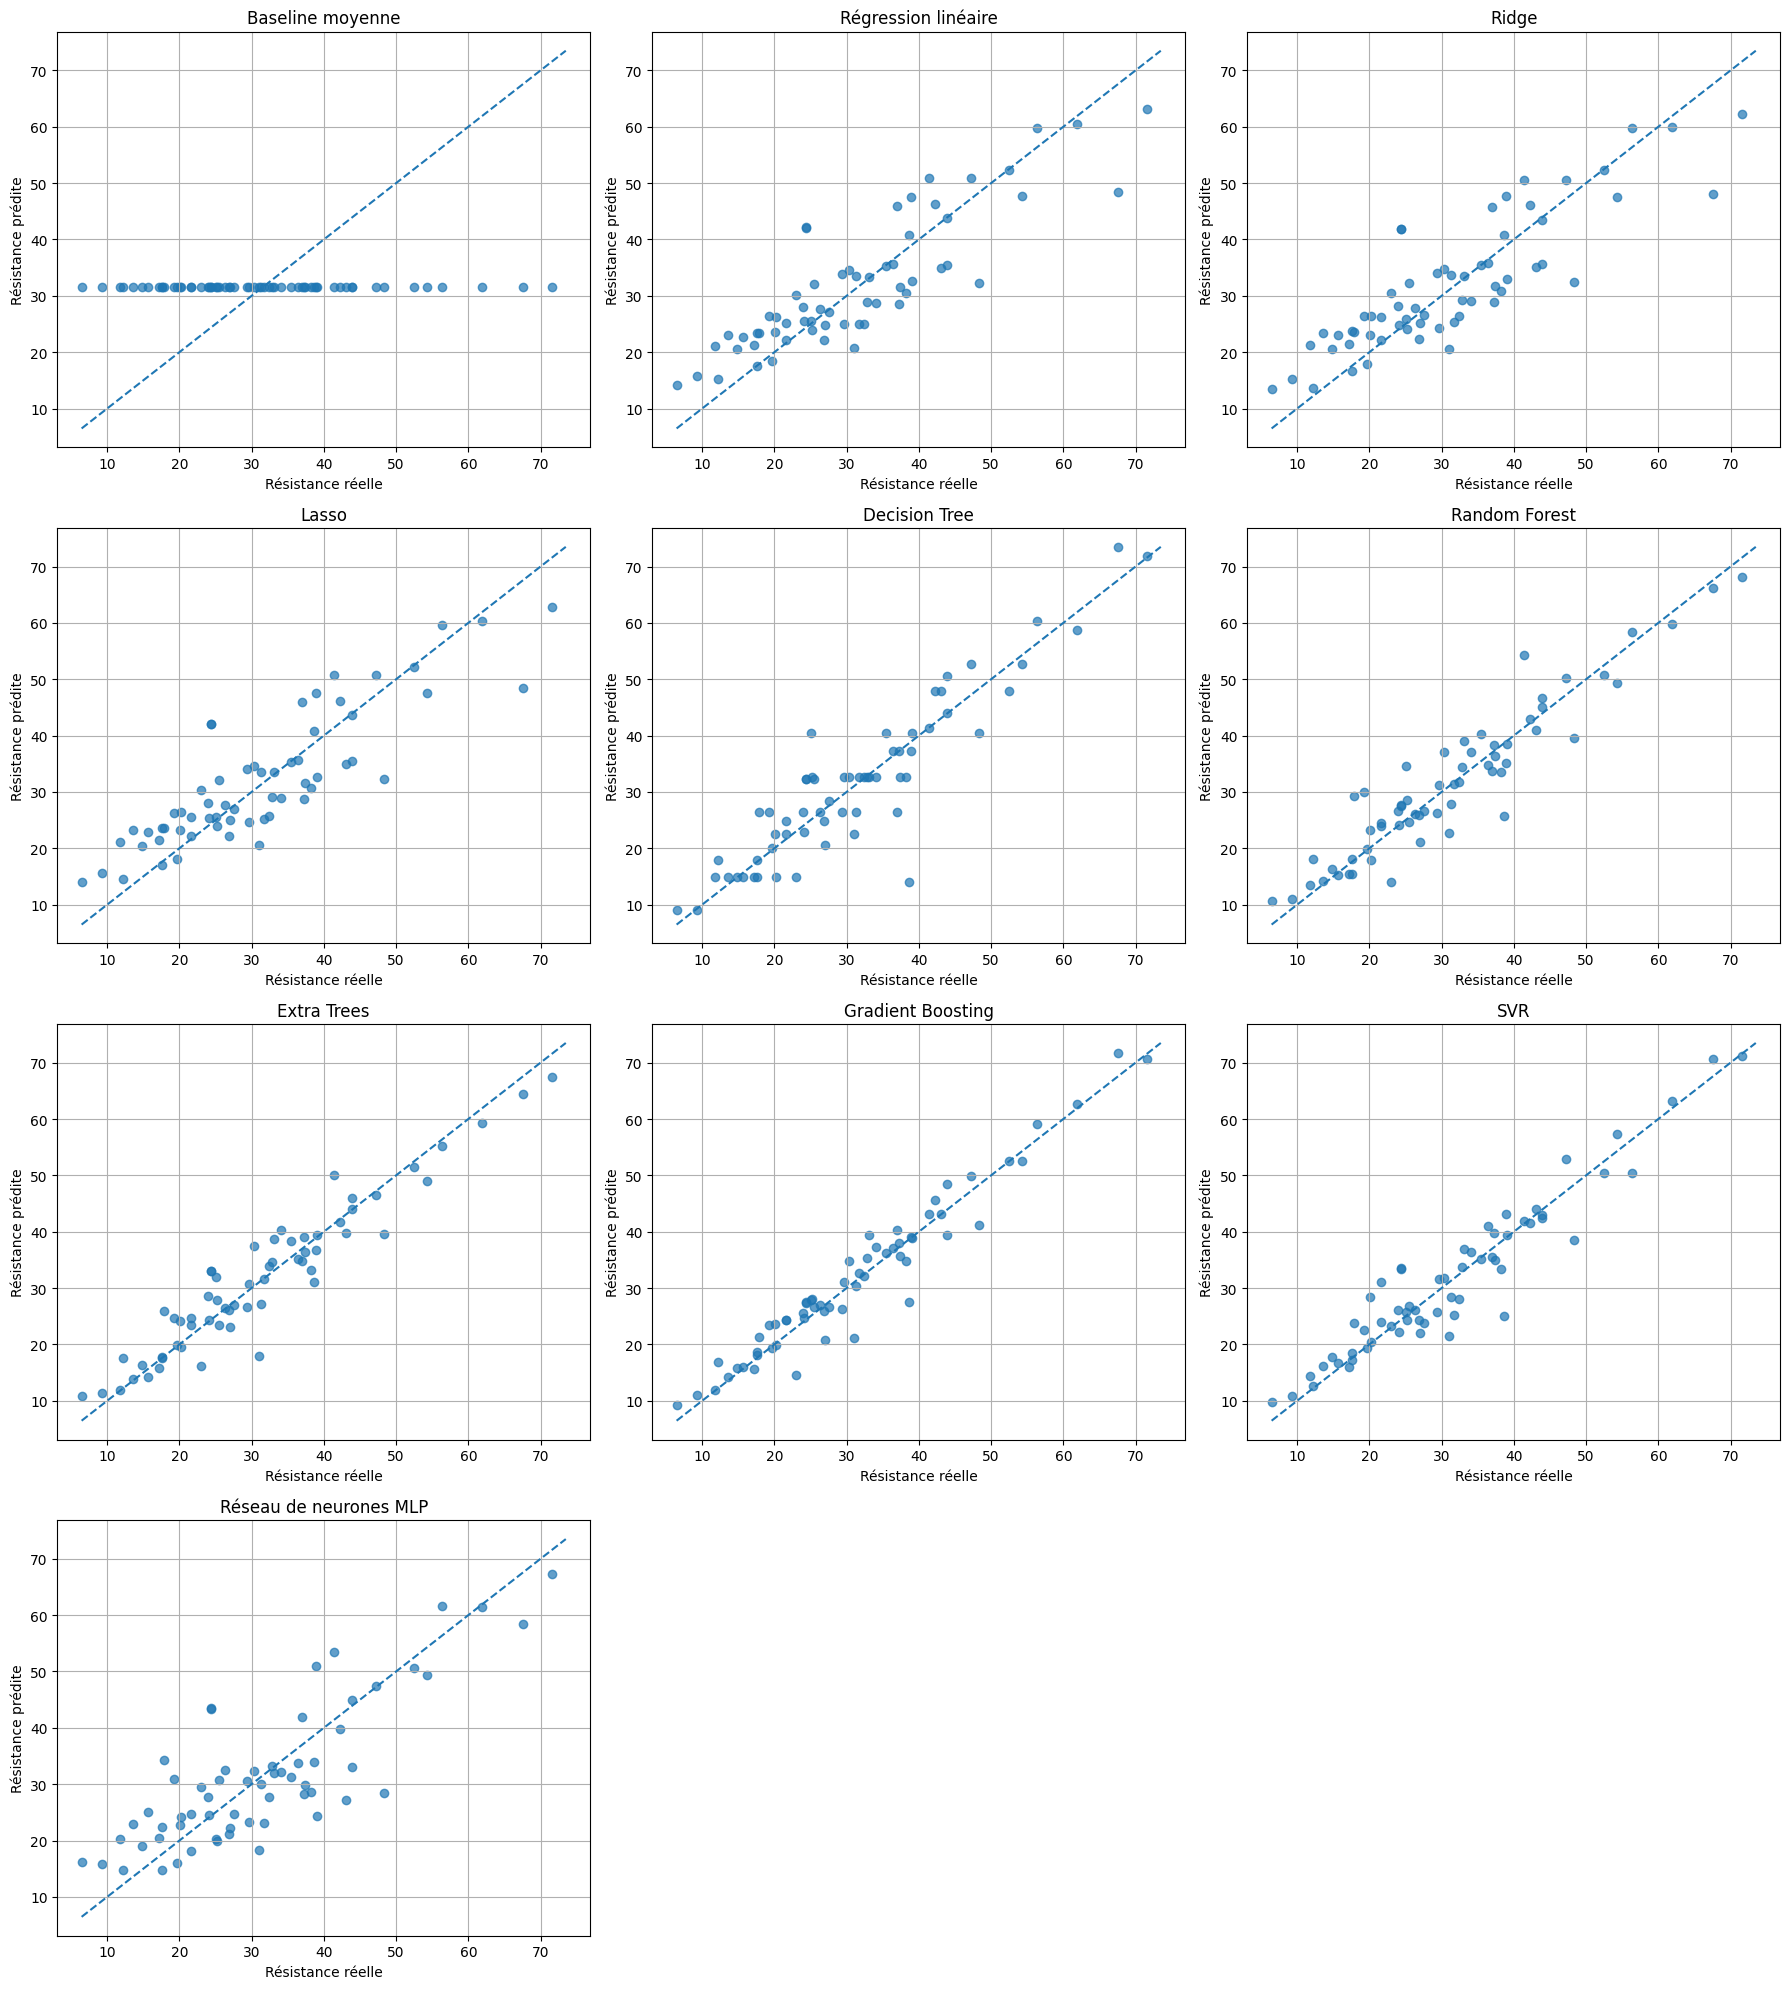

In [13]:
n_models = len(results)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

min_val = min(y_test.min(), min(np.min(r["y_pred"]) for r in results))
max_val = max(y_test.max(), max(np.max(r["y_pred"]) for r in results))

for i, r in enumerate(results):
    axes[i].scatter(y_test, r["y_pred"], alpha=0.7)
    axes[i].plot([min_val, max_val], [min_val, max_val], linestyle="--")
    axes[i].set_title(r["Modèle"])
    axes[i].set_xlabel("Résistance réelle")
    axes[i].set_ylabel("Résistance prédite")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 14. Analyse des résidus

### Utilité dans le projet

Le résidu est la différence :

> résistance réelle - résistance prédite

L'analyse des résidus permet de savoir si un modèle :

- fait des erreurs aléatoires ;
- surestime régulièrement certaines résistances ;
- sous-estime les bétons à forte résistance ;
- présente des erreurs dangereuses pour l'utilisation pratique.

En génie civil, une sous-estimation ou une surestimation importante peut avoir des conséquences différentes selon le contexte.

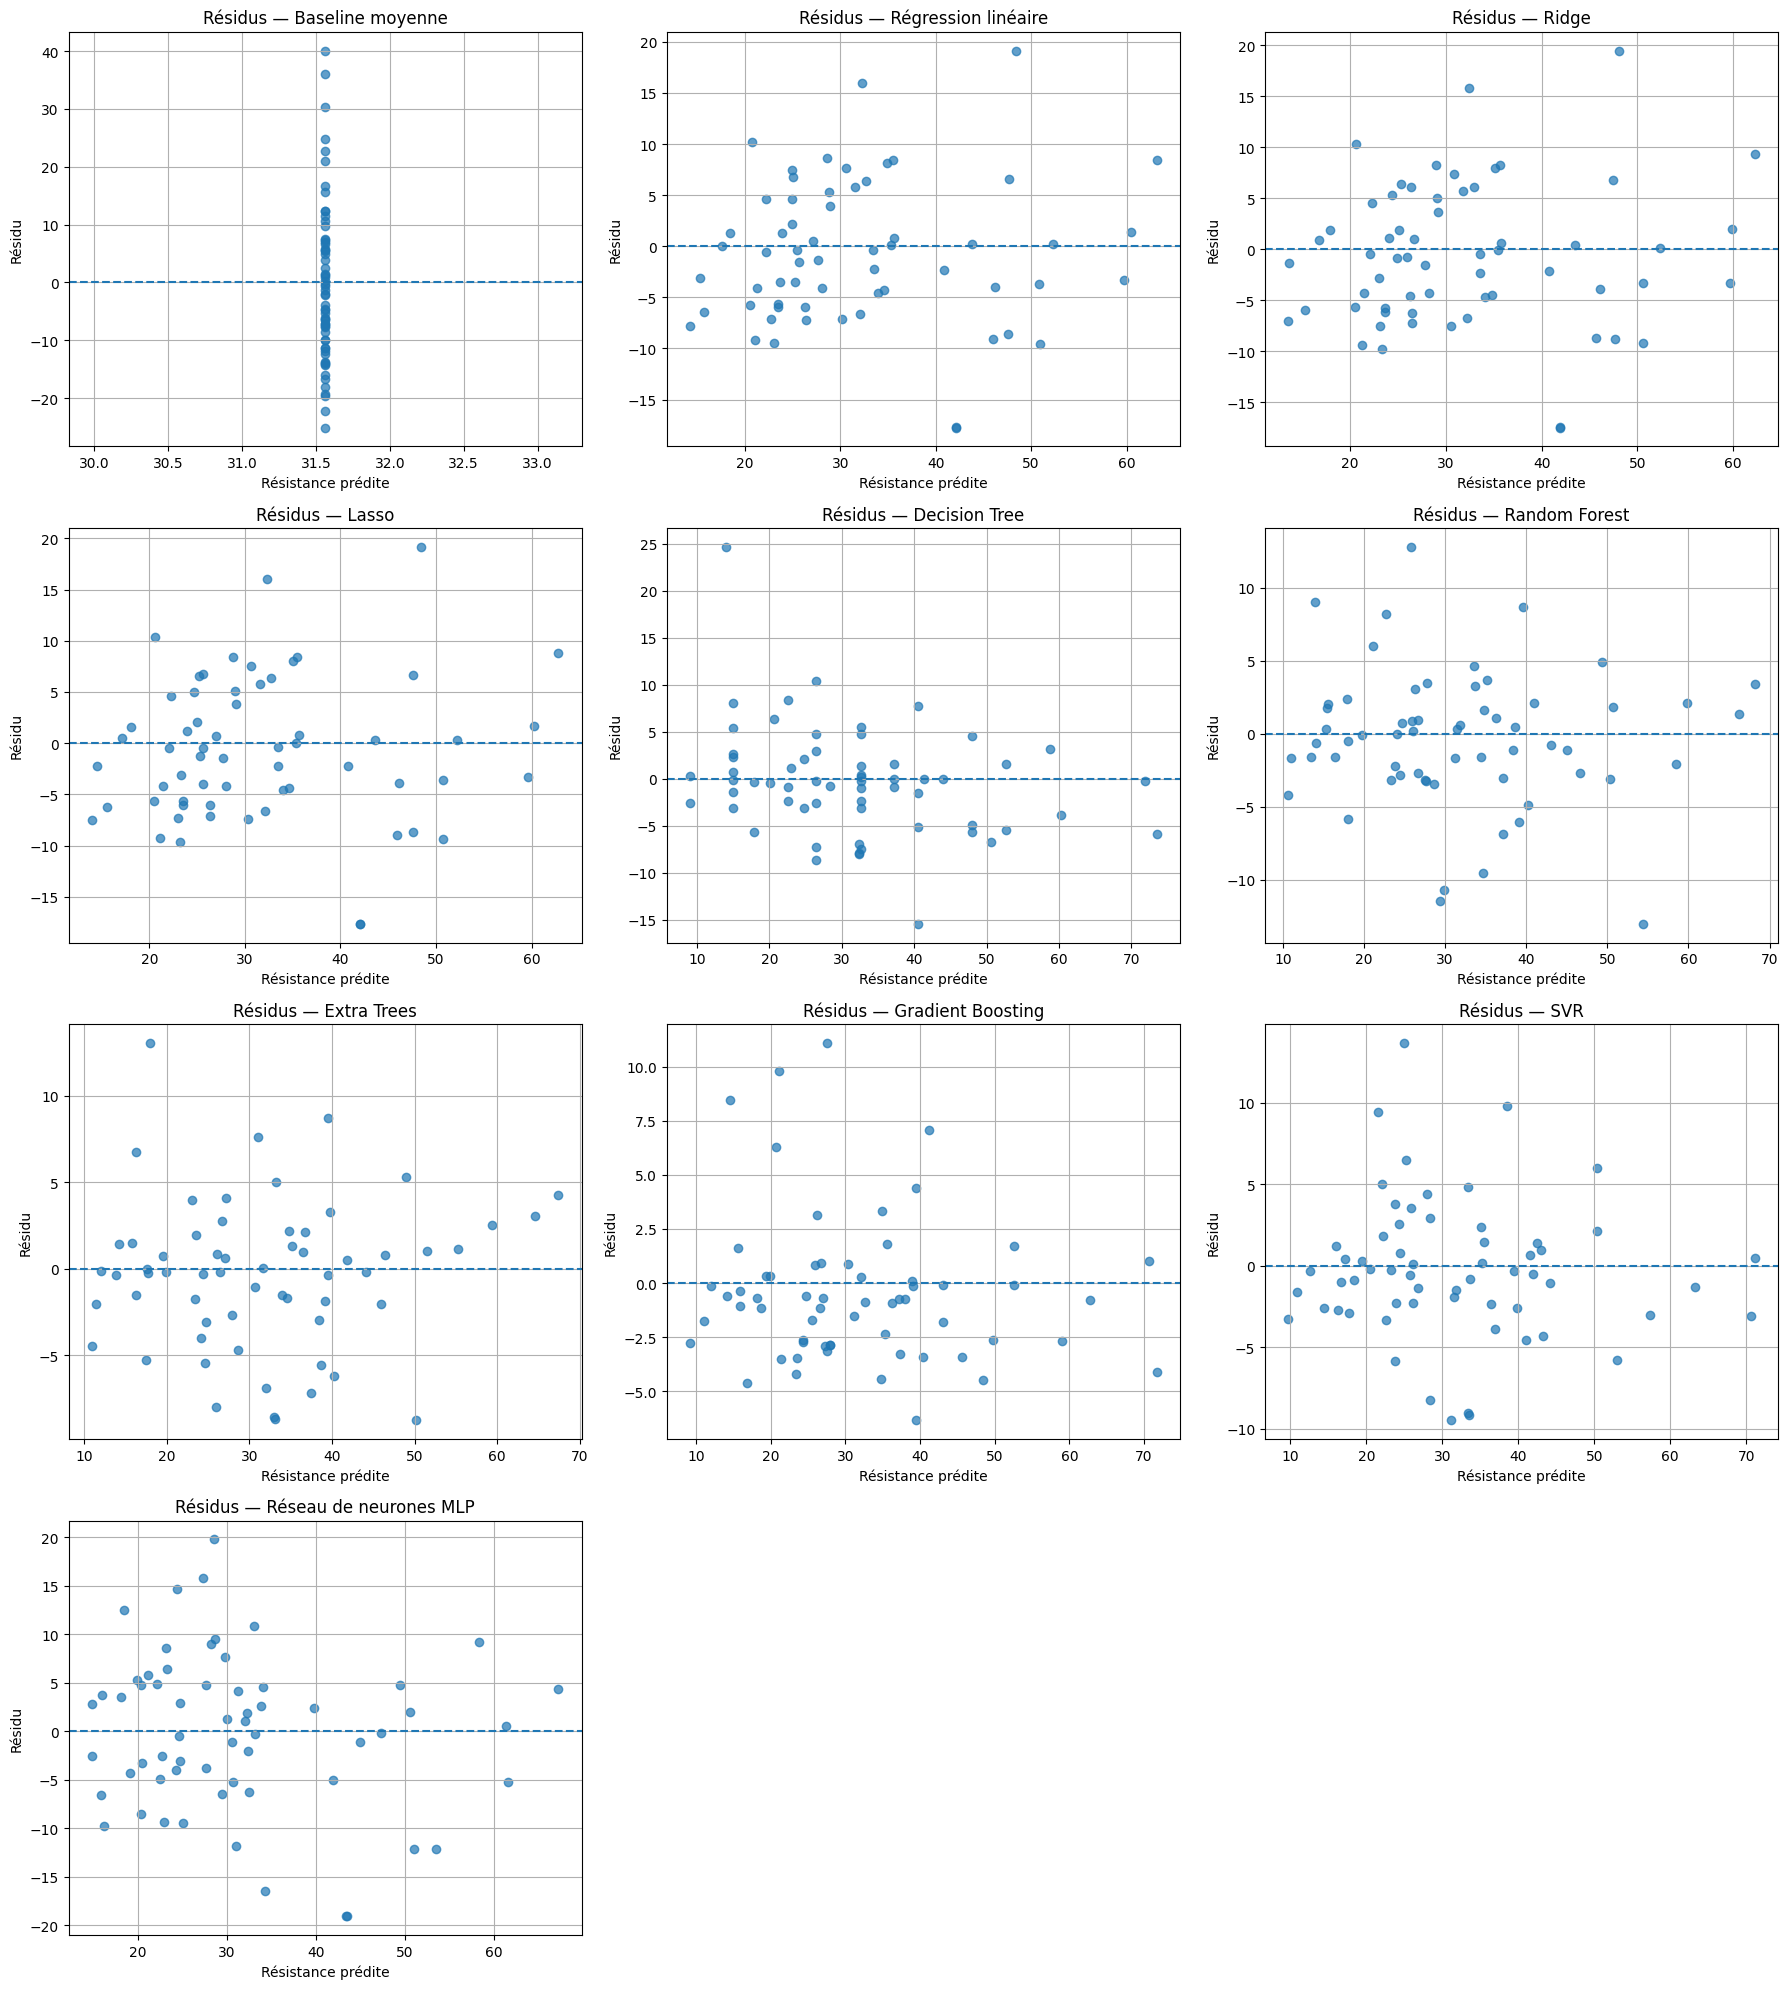

In [14]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, r in enumerate(results):
    residuals = y_test - r["y_pred"]
    axes[i].scatter(r["y_pred"], residuals, alpha=0.7)
    axes[i].axhline(0, linestyle="--")
    axes[i].set_title(f"Résidus — {r['Modèle']}")
    axes[i].set_xlabel("Résistance prédite")
    axes[i].set_ylabel("Résidu")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 15. Distribution des erreurs absolues

### Utilité dans le projet

Cette section montre la distribution des erreurs absolues.

Elle permet de répondre à des questions très pratiques :

- combien d'erreurs sont inférieures à 2 MPa ?
- combien d'erreurs dépassent 5 MPa ?
- le modèle est-il suffisamment précis pour une aide à la décision ?

Pour un usage industriel, il ne suffit pas d'avoir une bonne moyenne : il faut aussi contrôler les grandes erreurs.

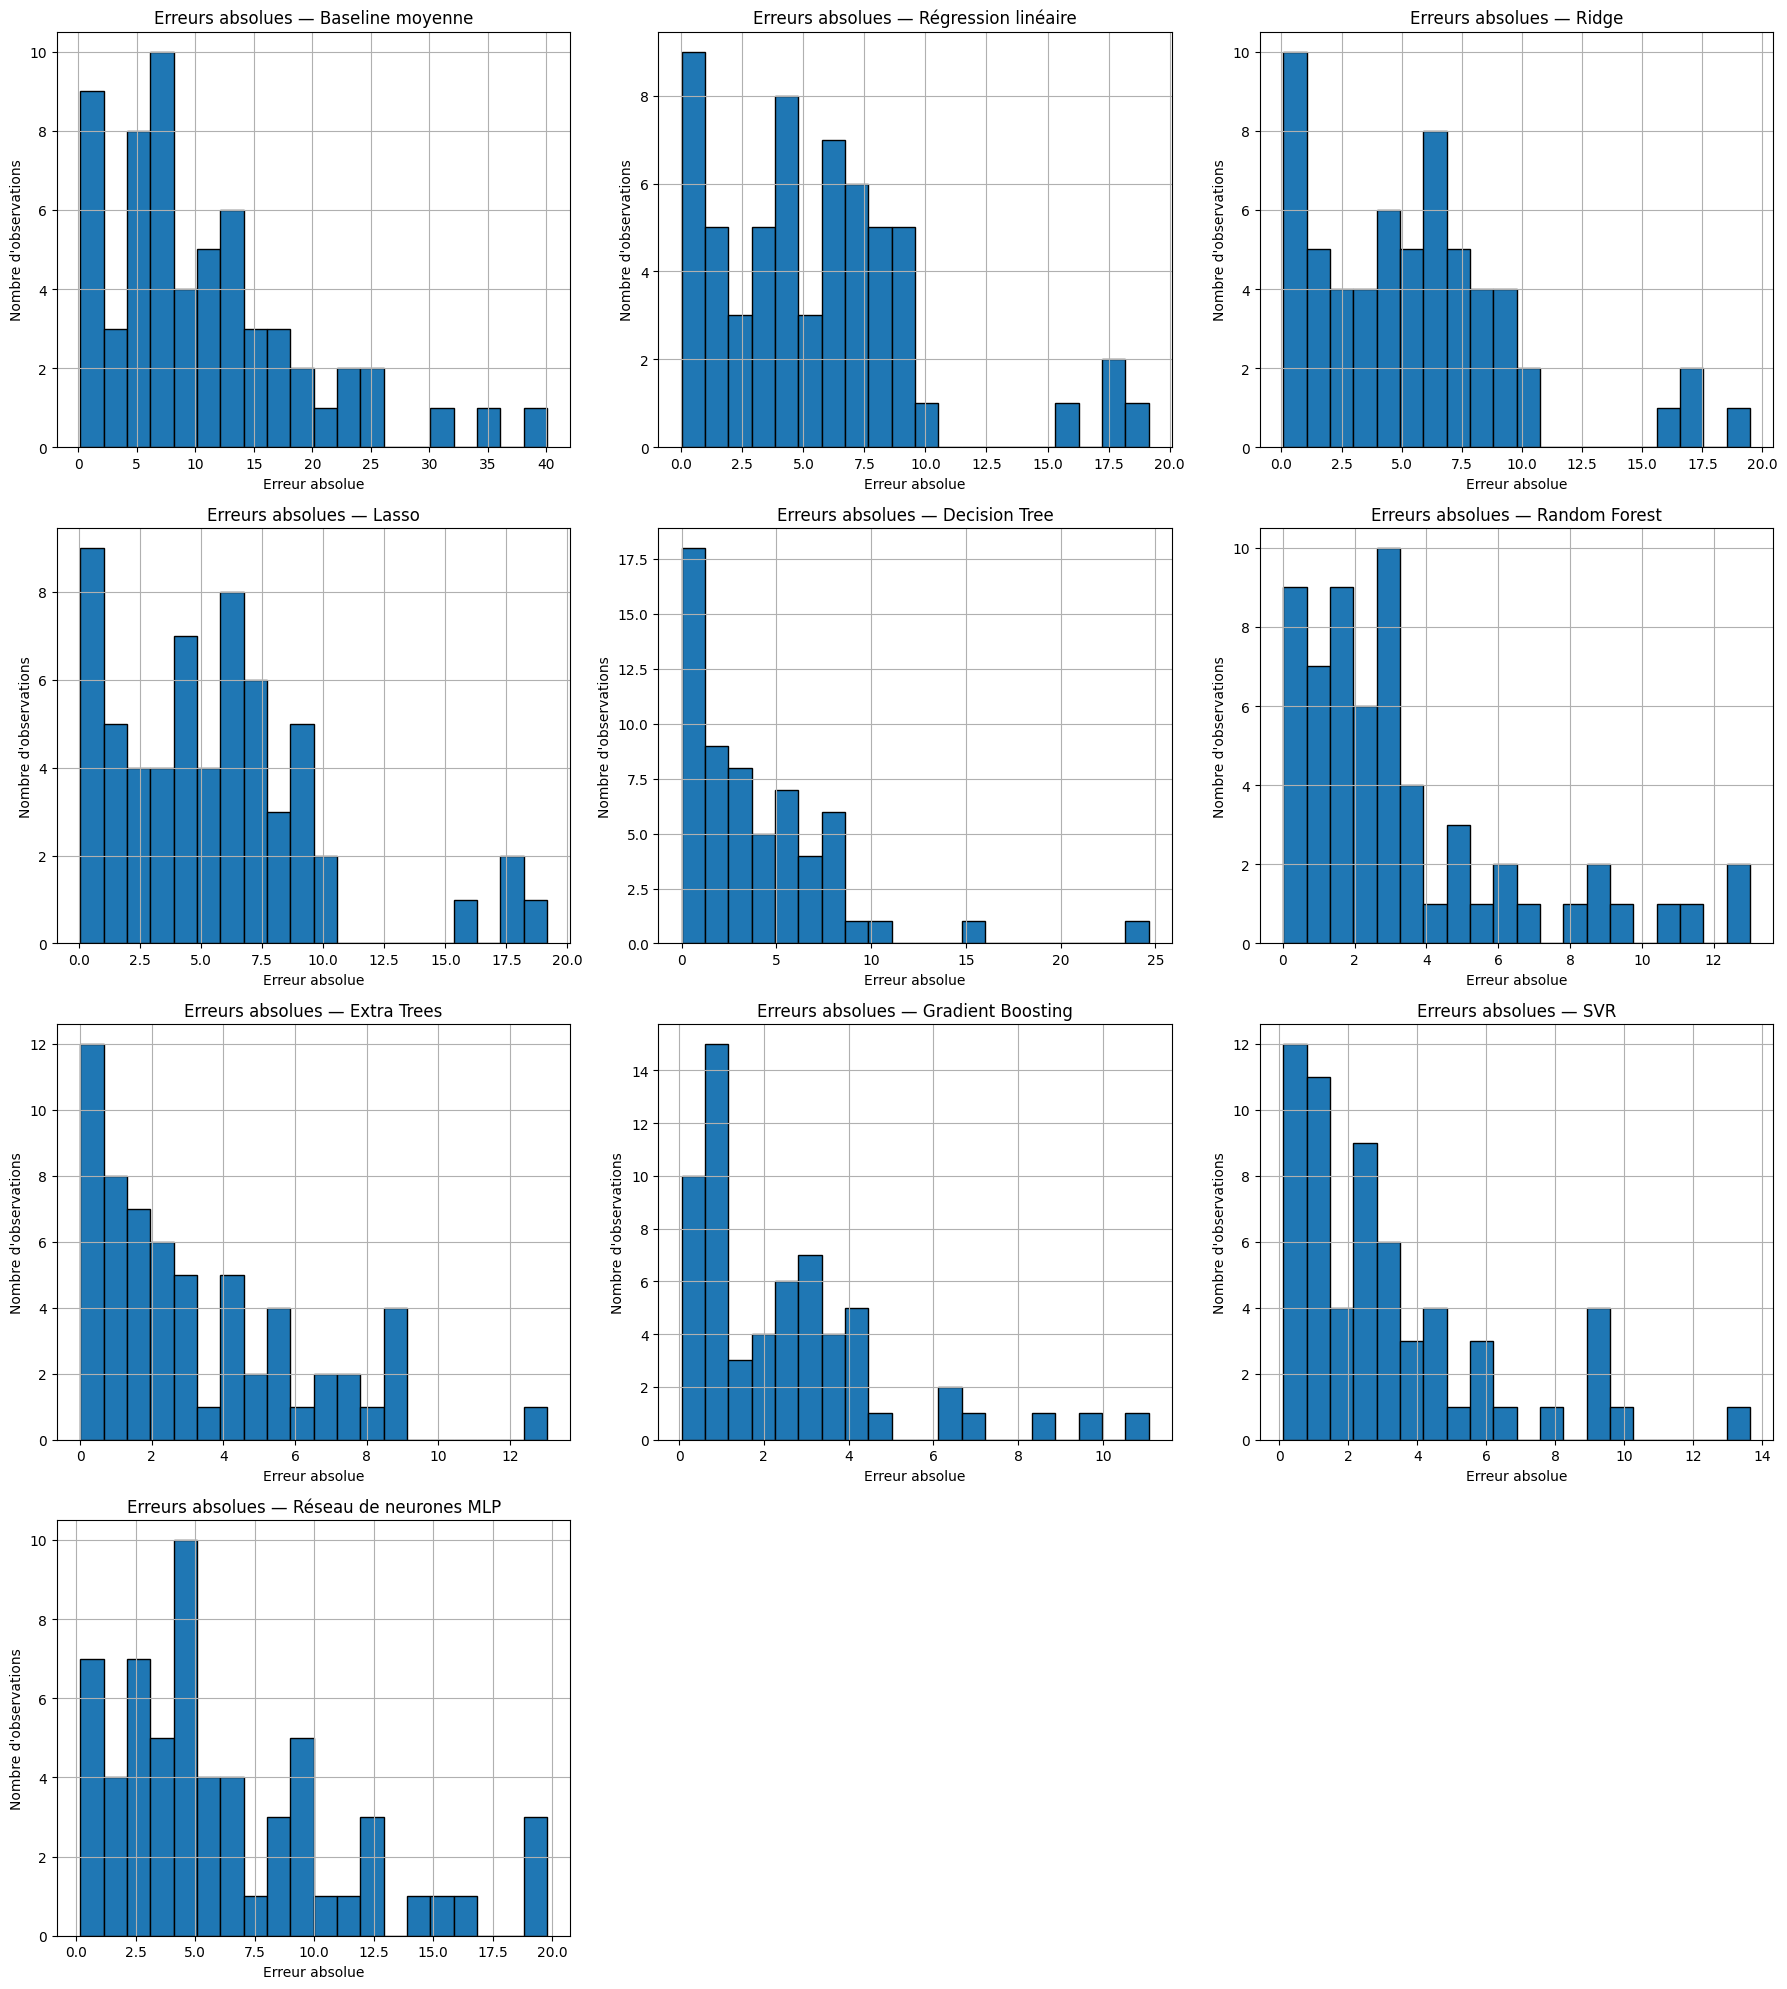

In [15]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, r in enumerate(results):
    abs_errors = np.abs(y_test - r["y_pred"])
    axes[i].hist(abs_errors, bins=20, edgecolor="black")
    axes[i].set_title(f"Erreurs absolues — {r['Modèle']}")
    axes[i].set_xlabel("Erreur absolue")
    axes[i].set_ylabel("Nombre d'observations")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

## 16. Sélection du meilleur modèle

### Utilité dans le projet

On choisit ici le modèle ayant le RMSE le plus faible sur le jeu de test.

Ce choix est une première indication.  
Dans un vrai projet industriel, il faudrait aussi considérer :

- la stabilité du modèle ;
- son interprétabilité ;
- sa facilité de déploiement ;
- la cohérence physique des résultats.

In [16]:
best_row = results_df.sort_values("RMSE").iloc[0]
best_name = best_row["Modèle"]

best_result = next(r for r in results if r["Modèle"] == best_name)
best_model = best_result["model"]
best_pred = best_result["y_pred"]

print("Meilleur modèle selon le RMSE :", best_name)
display(best_row.to_frame().T)

Meilleur modèle selon le RMSE : Gradient Boosting


,Modèle,MAE,RMSE,R2
7,Gradient Boosting,2.517,3.439,0.938


## 17. Validation croisée

### Utilité dans le projet

La validation croisée permet d'évaluer la stabilité d'un modèle.

Au lieu de dépendre d'une seule séparation apprentissage/test, on répète l'évaluation sur plusieurs découpages.

Dans notre projet, c'est important car le dataset fusionné peut contenir des formulations très différentes.  
Un modèle stable doit rester performant même lorsque le découpage des données change.

,Modèle,RMSE moyen CV,Écart-type RMSE CV
6,Gradient Boosting,4.271,0.833
4,Random Forest,5.131,0.451
5,Extra Trees,5.172,0.699
3,Decision Tree,6.043,0.655
7,SVR,6.181,1.017
1,Ridge,9.476,1.414
2,Lasso,9.488,1.429
0,Régression linéaire,9.492,1.428
8,Réseau de neurones MLP,11.946,3.371


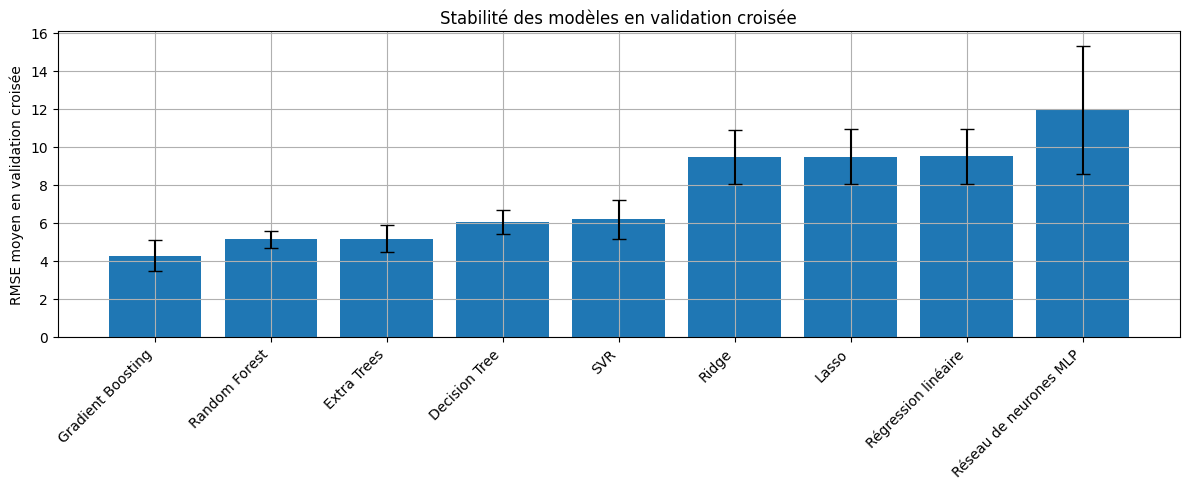

In [17]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {r["Modèle"]: r["model"] for r in results if r["model"] is not None}

cv_results = []

for name, model in cv_models.items():
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="neg_root_mean_squared_error",
        cv=cv
    )
    rmse_scores = -scores
    cv_results.append({
        "Modèle": name,
        "RMSE moyen CV": rmse_scores.mean(),
        "Écart-type RMSE CV": rmse_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("RMSE moyen CV")
display(cv_df)

plt.figure(figsize=(12, 5))
plt.bar(cv_df["Modèle"], cv_df["RMSE moyen CV"], yerr=cv_df["Écart-type RMSE CV"], capsize=5)
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE moyen en validation croisée")
plt.title("Stabilité des modèles en validation croisée")
plt.tight_layout()
plt.show()

## 18. Importance des variables pour les modèles à arbres

### Utilité dans le projet

Les modèles à arbres permettent d'estimer l'importance relative des variables.

Cette étape aide à répondre à des questions métier :

- le rapport `E/C` est-il très influent ?
- l'âge joue-t-il un rôle important ?
- le ciment est-il dominant ?
- les granulats influencent-ils fortement la résistance ?

Attention : l'importance des variables est un indicateur statistique du modèle, pas une loi physique absolue.

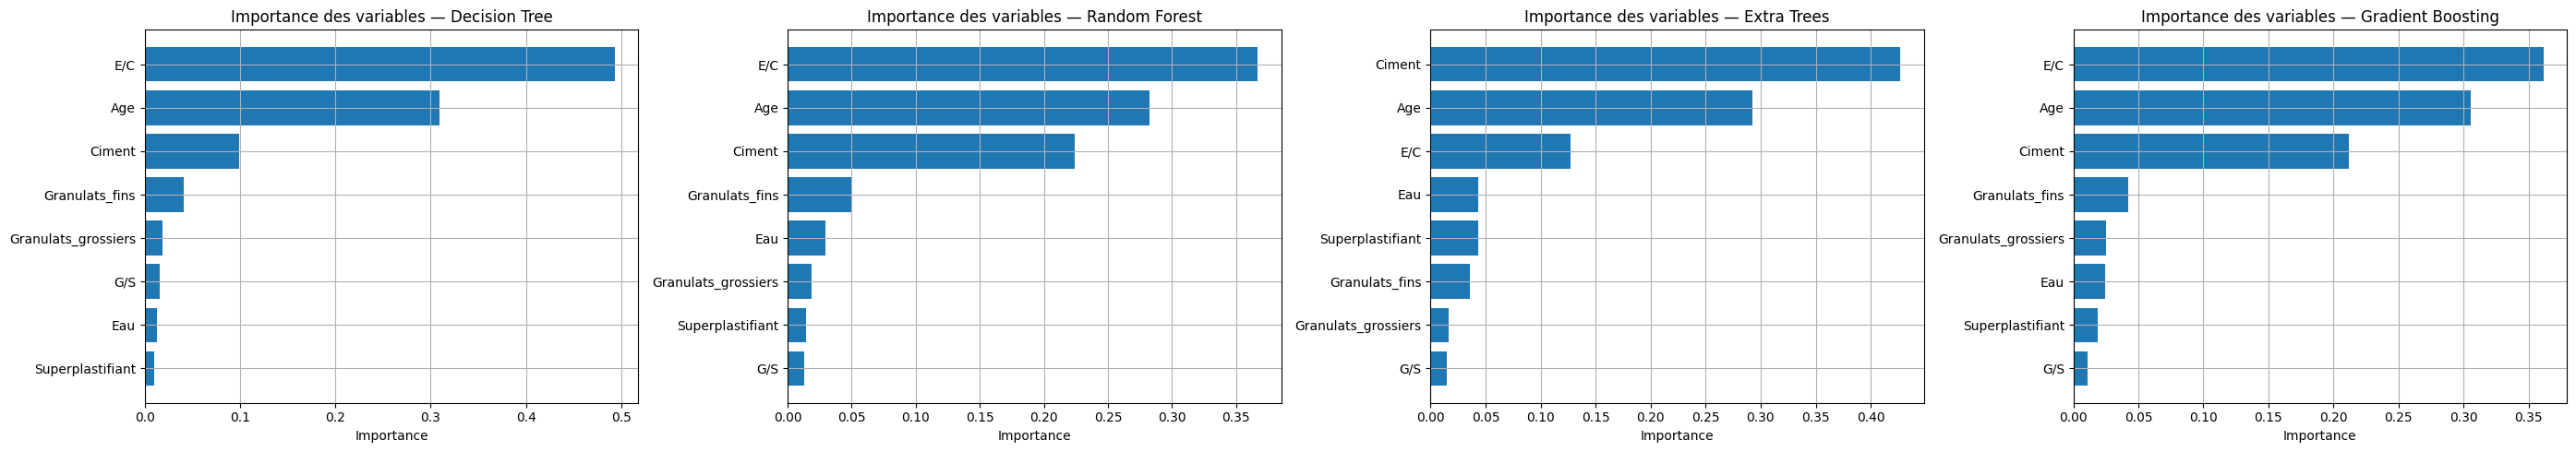

In [18]:
tree_importance_models = {}

for r in results:
    model = r["model"]
    name = r["Modèle"]
    if hasattr(model, "feature_importances_"):
        tree_importance_models[name] = model

if tree_importance_models:
    n = len(tree_importance_models)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))

    if n == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, tree_importance_models.items()):
        importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()
        ax.barh(importances.index, importances.values)
        ax.set_title(f"Importance des variables — {name}")
        ax.set_xlabel("Importance")

    plt.tight_layout()
    plt.show()
else:
    print("Aucun modèle à arbres avec feature_importances_ disponible.")

## 19. Courbe d'apprentissage du meilleur modèle

### Utilité dans le projet

La courbe d'apprentissage montre comment les performances changent lorsque la taille du jeu d'apprentissage augmente.

Elle permet de diagnostiquer :

- si le modèle manque de données ;
- si le modèle est trop simple ;
- si le modèle sur-apprend ;
- si l'ajout de nouvelles formulations expérimentales pourrait améliorer les performances.

Dans une centrale à béton, cette analyse peut aider à décider s'il est utile de produire davantage d'essais pour enrichir la base de données.

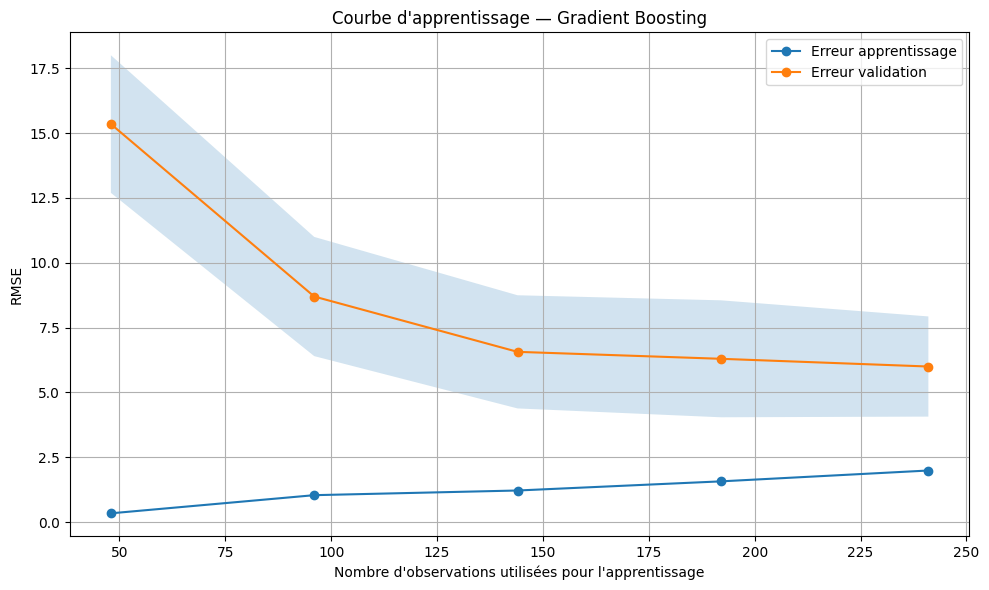

In [19]:
if best_model is not None:
    train_sizes, train_scores, val_scores = learning_curve(
        best_model,
        X,
        y,
        cv=5,
        scoring="neg_root_mean_squared_error",
        train_sizes=np.linspace(0.2, 1.0, 5),
        random_state=42
    )

    train_rmse = -train_scores
    val_rmse = -val_scores

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_rmse.mean(axis=1), marker="o", label="Erreur apprentissage")
    plt.plot(train_sizes, val_rmse.mean(axis=1), marker="o", label="Erreur validation")
    plt.fill_between(
        train_sizes,
        val_rmse.mean(axis=1) - val_rmse.std(axis=1),
        val_rmse.mean(axis=1) + val_rmse.std(axis=1),
        alpha=0.2
    )
    plt.xlabel("Nombre d'observations utilisées pour l'apprentissage")
    plt.ylabel("RMSE")
    plt.title(f"Courbe d'apprentissage — {best_name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 20. Analyse des erreurs les plus importantes

### Utilité dans le projet

Cette section identifie les formulations où le modèle se trompe le plus.

Ces cas sont très importants en génie civil car ils peuvent révéler :

- des formulations atypiques ;
- des valeurs expérimentales bruitées ;
- des zones mal représentées dans le dataset ;
- des limites du modèle.

L'ingénieur peut ensuite décider s'il faut contrôler ces formulations ou ajouter des essais similaires.

10 formulations avec les plus grandes erreurs absolues :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance_reelle,Resistance_predite,Erreur,Erreur_absolue
7,475.0,228.0,0.00,932.000,594.000,1.569,0.480,7,38.60,27.520,11.080,11.080
137,297.0,186.0,0.00,1040.000,734.000,1.417,0.626,7,30.96,21.160,9.800,9.800
232,370.0,190.0,0.00,1316.000,810.000,1.625,0.514,7,23.00,14.554,8.446,8.446
271,380.0,190.0,2.62,1122.000,615.000,1.824,0.500,28,48.30,41.238,7.062,7.062
57,397.0,185.7,0.00,1040.600,734.300,1.417,0.468,28,33.08,39.406,-6.326,6.326
73,339.0,197.0,0.00,968.000,781.000,1.239,0.581,14,27.04,20.771,6.269,6.269
101,200.0,180.0,0.00,1125.000,845.000,1.331,0.900,28,12.25,16.869,-4.619,4.619
42,480.0,192.0,0.00,936.200,712.200,1.315,0.400,28,43.94,48.395,-4.455,4.455
251,400.0,193.0,1.40,1213.000,619.000,1.960,0.482,28,30.29,34.726,-4.436,4.436
299,400.0,175.0,3.00,1138.978,705.274,1.615,0.438,28,43.89,39.494,4.396,4.396


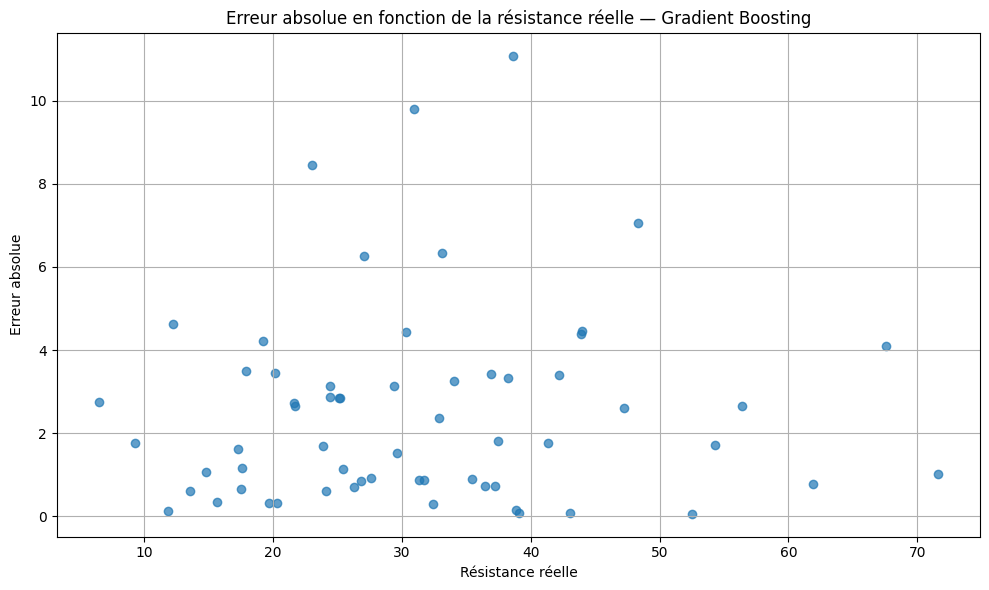

In [20]:
error_analysis = X_test.copy()
error_analysis["Resistance_reelle"] = y_test.values
error_analysis["Resistance_predite"] = best_pred
error_analysis["Erreur"] = error_analysis["Resistance_reelle"] - error_analysis["Resistance_predite"]
error_analysis["Erreur_absolue"] = np.abs(error_analysis["Erreur"])

print("10 formulations avec les plus grandes erreurs absolues :")
display(error_analysis.sort_values("Erreur_absolue", ascending=False).head(10))

plt.figure(figsize=(10, 6))
plt.scatter(error_analysis["Resistance_reelle"], error_analysis["Erreur_absolue"], alpha=0.7)
plt.xlabel("Résistance réelle")
plt.ylabel("Erreur absolue")
plt.title(f"Erreur absolue en fonction de la résistance réelle — {best_name}")
plt.tight_layout()
plt.show()

## 21. Comparaison avec l'article scientifique de Nasser et al.

### Rappel de l'article

L'article de Nasser et al. étudie l'utilisation des réseaux de neurones artificiels pour :

1. prédire les performances d'un béton à partir de sa composition ;
2. proposer une formulation à partir de performances souhaitées.

Dans leur étude :

- 81 formulations de béton ont été préparées ;
- 69 formulations ont servi à l'apprentissage ;
- 12 formulations ont servi à la validation ;
- les performances étudiées incluent la résistance à 28 jours et l'affaissement à 0, 30 et 60 minutes ;
- le réseau de neurones a donné de meilleurs résultats que plusieurs méthodes classiques ;
- l'erreur moyenne sur la résistance était d'environ 4,9 %, soit environ 1,5 MPa pour les bétons ordinaires.

### Comparaison avec notre projet

Notre projet suit le même esprit :

> utiliser les données expérimentales pour apprendre la relation entre formulation et résistance.

Mais il existe des différences importantes :

| Point comparé | Article de Nasser et al. | Notre projet |
|---|---|---|
| Type d'approche | Réseaux de neurones | Plusieurs modèles ML |
| Objectif | Formulation + prédiction | Prédiction puis préparation à la formulation inverse |
| Données | 81 formulations | Dataset fusionné plus volumineux |
| Variables | Ciment, eau, sable, gravier, superplastifiant | Colonnes disponibles dans le CSV fusionné |
| Performances | Résistance + affaissement | Résistance principalement |
| Sortie principale ici | fc28 / résistance | `Resistance` |

### Limite importante

Notre dataset actuel ne contient pas explicitement l'affaissement `slump`.  
Donc la comparaison avec l'article est partielle : on peut comparer la prédiction de la résistance, mais pas encore la prédiction de l'ouvrabilité.

Pour traiter complètement la formulation demandée par un client, il faudrait disposer de performances comme :

- résistance cible ;
- affaissement initial ;
- perte d'affaissement après transport ;
- classe de consistance ;
- coût ;
- contraintes de dosage.

Ce notebook constitue donc une première étape vers cette approche.

In [21]:
# Comparaison numérique indicative avec l'article de Nasser et al.
# L'article annonce une erreur moyenne d'environ 4,9 % pour la résistance.
# On calcule ici l'erreur relative moyenne du meilleur modèle sur notre jeu de test.

relative_error = np.mean(np.abs((y_test - best_pred) / y_test)) * 100

comparison_article = pd.DataFrame({
    "Indicateur": [
        "Erreur relative moyenne sur la résistance",
        "RMSE du meilleur modèle",
        "MAE du meilleur modèle",
        "R² du meilleur modèle"
    ],
    "Notre projet": [
        f"{relative_error:.2f} %",
        f"{best_row['RMSE']:.3f}",
        f"{best_row['MAE']:.3f}",
        f"{best_row['R2']:.3f}"
    ],
    "Article de Nasser et al.": [
        "≈ 4,9 %",
        "Non exprimé de la même manière dans le résumé",
        "Non exprimé de la même manière dans le résumé",
        "Non directement comparable"
    ]
})

display(comparison_article)

,Indicateur,Notre projet,Article de Nasser et al.
0,Erreur relative moyenne sur la résistance,9.57 %,"≈ 4,9 %"
1,RMSE du meilleur modèle,3.439,Non exprimé de la même manière dans le résumé
2,MAE du meilleur modèle,2.517,Non exprimé de la même manière dans le résumé
3,R² du meilleur modèle,0.938,Non directement comparable


## 22. Aide à la décision : prédire la résistance d'une formulation

### Utilité dans le projet

Une fois le meilleur modèle entraîné, on peut l'utiliser pour estimer la résistance d'une nouvelle formulation.

Cette étape répond à une question métier très concrète :

> Si je propose cette composition, quelle résistance puis-je espérer ?

Dans ce notebook, on donne un exemple à partir d'une formulation déjà existante dans le dataset.  
L'utilisateur peut ensuite modifier les valeurs pour tester une autre formulation.

Aucune nouvelle colonne n'est créée dans le dataset.

In [22]:
# Exemple : on prend une formulation existante comme exemple de saisie
example = X.iloc[[0]].copy()

print("Formulation exemple utilisée pour la prédiction :")
display(example)

predicted_strength = best_model.predict(example)[0] if best_model is not None else y_train.mean()

print(f"Résistance prédite par le meilleur modèle ({best_name}) : {predicted_strength:.2f}")
print(f"Résistance réelle dans le dataset : {y.iloc[0]:.2f}")

Formulation exemple utilisée pour la prédiction :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age
0,540.0,162.0,2.5,1040.0,676.0,1.538,0.3,28


Résistance prédite par le meilleur modèle (Gradient Boosting) : 73.88
Résistance réelle dans le dataset : 79.99


## 23. Recherche de formulations proches d'une résistance cible

### Utilité dans le projet

Cette section prépare l'idée de formulation inverse.

Question métier :

> Le client demande une résistance cible. Quelles formulations existantes dans la base sont les plus proches ?

Ici, on ne génère pas encore une nouvelle formulation optimisée.  
On recherche simplement dans le dataset les formulations existantes dont la résistance est proche de la résistance demandée.

Cette approche est simple, pédagogique et utile pour un premier outil d'aide à la décision.

In [23]:
def find_existing_formulations_by_strength(target_strength, n=10):
    """Retourne les formulations existantes les plus proches d'une résistance cible."""
    temp = df.copy()
    # Cette colonne est créée uniquement dans une copie temporaire pour le classement,
    # elle n'est pas ajoutée au dataset principal.
    temp["_ecart_temporaire"] = np.abs(temp["Resistance"] - target_strength)
    return temp.sort_values("_ecart_temporaire").drop(columns=["_ecart_temporaire"]).head(n)

target_strength = 40

print(f"Formulations existantes les plus proches de {target_strength} MPa :")
display(find_existing_formulations_by_strength(target_strength, n=10))

Formulations existantes les plus proches de 40 MPa :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C,Age,Resistance
41,393.0,192.0,0.0,940.6,785.6,1.197,0.489,28,39.60
201,393.0,192.0,0.0,940.0,758.0,1.240,0.489,28,39.58
187,349.0,192.0,0.0,1047.0,806.0,1.299,0.550,90,39.49
127,331.0,192.0,0.0,1025.0,821.0,1.248,0.580,120,39.38
131,349.0,192.0,0.0,1056.0,809.0,1.305,0.550,90,40.66
247,400.0,190.0,2.4,1134.0,631.0,1.797,0.475,28,40.69
2,475.0,228.0,0.0,932.0,594.0,1.569,0.480,28,39.29
132,349.0,192.0,0.0,1056.0,809.0,1.305,0.550,120,40.86
222,397.0,185.0,0.0,1040.0,734.0,1.417,0.466,28,39.09
231,374.3,190.2,6.7,1013.2,730.4,1.387,0.508,28,39.06


## 24. Modèle inverse simple : Performance → Composition

### Utilité dans le projet

L'article de Nasser et al. propose aussi une approche inverse :

> à partir de performances exigées, estimer une composition possible.

Dans notre dataset actuel, la performance disponible est surtout `Resistance`.  
On peut donc construire une version simplifiée :

> `Resistance` → estimation des composants de formulation

Cette approche est limitée, car plusieurs compositions différentes peuvent donner une résistance proche.  
Donc le résultat doit être vu comme une **aide à la proposition**, pas comme une formulation définitive.


In [24]:
# Choix des colonnes de composition à prédire
composition_cols = [col for col in feature_cols if col != "Age"]

# Entrées du modèle inverse : uniquement les variables de performance disponibles
# Ici, on utilise Resistance, et Age si l'on souhaite fixer l'âge d'essai.
inverse_input_cols = ["Resistance"]

if "Age" in df.columns:
    inverse_input_cols = ["Resistance", "Age"]

X_inverse = df[inverse_input_cols].copy()
Y_inverse = df[composition_cols].copy()

X_inv_train, X_inv_test, Y_inv_train, Y_inv_test = train_test_split(
    X_inverse,
    Y_inverse,
    test_size=0.20,
    random_state=42
)

inverse_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))
])

inverse_model.fit(X_inv_train, Y_inv_train)

Y_inv_pred = inverse_model.predict(X_inv_test)

inverse_mae = mean_absolute_error(Y_inv_test, Y_inv_pred)
inverse_rmse = np.sqrt(mean_squared_error(Y_inv_test, Y_inv_pred))

print("Modèle inverse simple : KNeighborsRegressor")
print("Entrées :", inverse_input_cols)
print("Sorties :", composition_cols)
print("MAE globale :", inverse_mae)
print("RMSE global :", inverse_rmse)

Modèle inverse simple : KNeighborsRegressor
Entrées : ['Resistance', 'Age']
Sorties : ['Ciment', 'Eau', 'Superplastifiant', 'Granulats_grossiers', 'Granulats_fins', 'G/S', 'E/C']
MAE globale : 35.85054348059531
RMSE global : 85.08588280348006


## 25. Exemple de formulation proposée à partir d'une résistance cible

### Utilité dans le projet

Cette cellule illustre une utilisation possible pour un ingénieur ou un technicien :

> Le client demande une résistance cible.  
> Le modèle inverse propose une composition approximative basée sur les données disponibles.

Cette proposition doit ensuite être vérifiée par :

- contraintes normatives ;
- disponibilité des matériaux ;
- coût ;
- ouvrabilité ;
- essais de laboratoire ;
- validation par l'ingénieur responsable.

Le modèle ne remplace pas l'expertise du génie civil.  
Il sert d'aide à la décision.

In [25]:
target_strength = 40

if "Age" in df.columns:
    target_age = 28
    client_request = pd.DataFrame([[target_strength, target_age]], columns=inverse_input_cols)
else:
    client_request = pd.DataFrame([[target_strength]], columns=inverse_input_cols)

proposed_composition = inverse_model.predict(client_request)
proposed_df = pd.DataFrame(proposed_composition, columns=composition_cols)

print("Demande client :")
display(client_request)

print("Composition approximative proposée par le modèle inverse :")
display(proposed_df)

# Vérification : on estime la résistance de la composition proposée avec le meilleur modèle direct.
# Si Age fait partie des variables du modèle direct et n'est pas dans la composition, on l'ajoute seulement dans l'exemple de prédiction,
# sans modifier le dataset principal.
direct_input = proposed_df.copy()

if "Age" in feature_cols and "Age" not in direct_input.columns:
    direct_input["Age"] = target_age

# Réordonner les colonnes selon le modèle direct
direct_input = direct_input[feature_cols]

estimated_strength = best_model.predict(direct_input)[0]

print(f"Résistance estimée de cette composition par le modèle direct : {estimated_strength:.2f}")

Demande client :


,Resistance,Age
0,40,28


Composition approximative proposée par le modèle inverse :


,Ciment,Eau,Superplastifiant,Granulats_grossiers,Granulats_fins,G/S,E/C
0,411.6,197.4,0.48,997.32,700.52,1.444,0.48


Résistance estimée de cette composition par le modèle direct : 34.11


## 26. Visualisation des formulations proposées et existantes

### Utilité dans le projet

Le but est de vérifier visuellement si la formulation proposée par le modèle inverse se situe dans la zone des formulations existantes.

Un modèle inverse peut être risqué s'il propose une composition trop éloignée du domaine connu.  
En génie civil, il est plus prudent de rester dans le domaine des formulations déjà observées, sauf validation expérimentale.

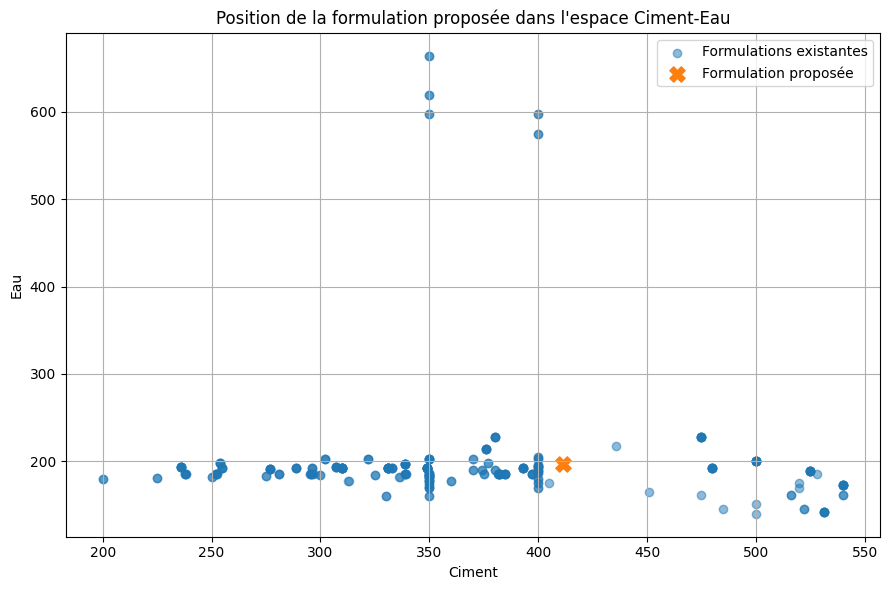

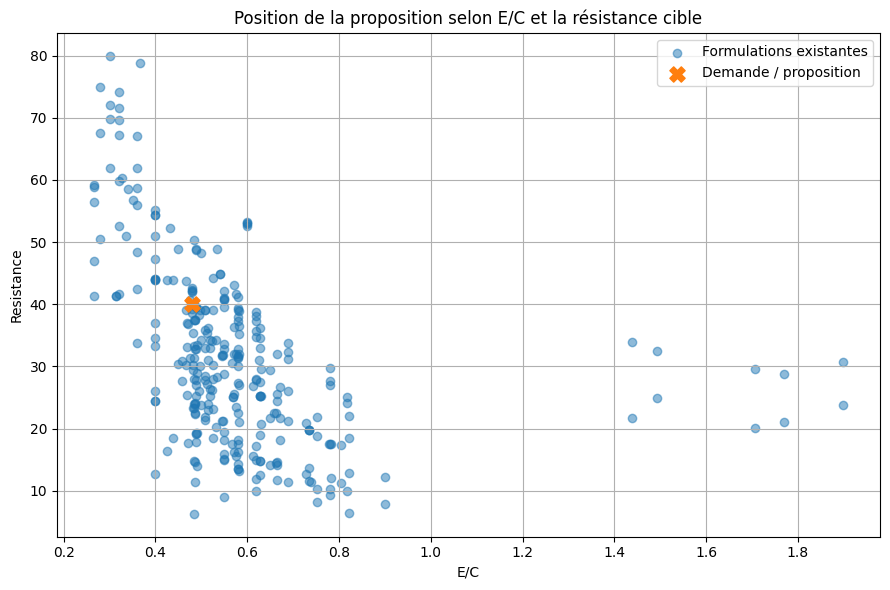

In [26]:
if "Ciment" in df.columns and "Eau" in df.columns and "Ciment" in proposed_df.columns and "Eau" in proposed_df.columns:
    plt.figure(figsize=(9, 6))
    plt.scatter(df["Ciment"], df["Eau"], alpha=0.5, label="Formulations existantes")
    plt.scatter(proposed_df["Ciment"], proposed_df["Eau"], s=120, marker="X", label="Formulation proposée")
    plt.xlabel("Ciment")
    plt.ylabel("Eau")
    plt.title("Position de la formulation proposée dans l'espace Ciment-Eau")
    plt.legend()
    plt.tight_layout()
    plt.show()

if "E/C" in df.columns and "Resistance" in df.columns and "E/C" in proposed_df.columns:
    plt.figure(figsize=(9, 6))
    plt.scatter(df["E/C"], df["Resistance"], alpha=0.5, label="Formulations existantes")
    plt.scatter(proposed_df["E/C"], [target_strength], s=120, marker="X", label="Demande / proposition")
    plt.xlabel("E/C")
    plt.ylabel("Resistance")
    plt.title("Position de la proposition selon E/C et la résistance cible")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 27. Synthèse finale

### Ce que ce notebook a permis de faire

1. Charger le dataset fusionné.
2. Utiliser uniquement les colonnes déjà présentes.
3. Entraîner plusieurs modèles de prédiction de la résistance :
   - baseline ;
   - modèles linéaires ;
   - modèles à arbres ;
   - SVR ;
   - réseau de neurones.
4. Comparer les modèles avec des métriques métier :
   - MAE ;
   - RMSE ;
   - R².
5. Visualiser les prédictions, les résidus et les erreurs.
6. Identifier les variables importantes pour les modèles à arbres.
7. Comparer la démarche avec l'article de Nasser et al.
8. Préparer une première approche de formulation inverse.

### Interprétation métier

Le meilleur modèle peut servir à estimer la résistance d'une formulation avant essai.  
Cependant, il ne remplace pas les essais de laboratoire.

Pour une utilisation industrielle, il faudra ensuite :

- valider le modèle sur de nouvelles formulations ;
- ajouter des données d'ouvrabilité si disponibles ;
- intégrer les contraintes normatives ;
- intégrer les coûts des matériaux ;
- contrôler les formulations proposées par le modèle inverse.

### Lien avec l'article de Nasser et al.

Comme dans l'article, l'idée principale est d'utiliser des données expérimentales pour apprendre la relation entre formulation et performance.

La différence principale est que notre notebook compare plusieurs familles de modèles, alors que l'article se concentre surtout sur les réseaux de neurones.